In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import mph
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

import mphsweepkit as msk

In [5]:
# Start the COMSOL client
client = mph.start()

In [6]:
# Load the model
model = client.load('core_cross_section_solved.mph')

Load an already solved CascadedSweepModel

In [7]:
csm = msk.CascadedSweepModel(model, 'Study on Cross-Sections')

Initialized CascadedSweepModel
Study name: Study on Cross-Sections
Sweep Structure:
    - Geometry Sweep (BatchSweep)
      - Material Sweep (MaterialSweep)
        - Excitation Sweep (Parametric)
          - Frequency Sweep (Frequency)
--------------------------------
Data updated from MPh-model.
Input data shape: (156, 8)
Reset output data to shape of the input data: (156, 0)
Combined shape: (156, 8)


Post-processing 

In [8]:
csm.model_datasets

['Study on Cross-Sections//Solution 1',
 'Study on Cross-Sections//Parametric Solutions 1']

In [9]:
# Load the customized post-processing expressions from a JSON file
post_processing_exprs = msk.load_post_processing_exprs("post_processing_expressions.json")

post_processing_expressions.json


In [10]:
csm.post_process(post_processing_exprs)

In [11]:
csm.combined_data

,hor_slit,vert_slit,w,l_r,a_e,matsw.comp1.core,b_mean,freq,p_loss,p_mag,p_el
0,0.0,0.0,5.0,0.0,5.0,2.0,25.0,100.0,1.065209e+03,1.016231e+03,4.897800e+01
1,0.0,0.0,5.0,0.0,5.0,2.0,25.0,200.0,2.817933e+03,2.542728e+03,2.752049e+02
2,0.0,0.0,5.0,0.0,5.0,2.0,25.0,300.0,5.421143e+03,4.629192e+03,7.919502e+02
3,0.0,0.0,5.0,0.0,5.0,2.0,25.0,400.0,9.291744e+03,7.584089e+03,1.707656e+03
4,0.0,0.0,5.0,0.0,5.0,2.0,25.0,500.0,1.497961e+04,1.185114e+04,3.128464e+03
...,...,...,...,...,...,...,...,...,...,...,...
151,0.0,0.0,15.0,0.0,15.0,2.0,100.0,900.0,6.288120e+06,3.096518e+06,3.191601e+06
152,0.0,0.0,15.0,0.0,15.0,2.0,100.0,1000.0,9.016708e+06,4.543201e+06,4.473508e+06
153,0.0,0.0,15.0,0.0,15.0,2.0,100.0,1100.0,1.238691e+07,6.479828e+06,5.907080e+06
154,0.0,0.0,15.0,0.0,15.0,2.0,100.0,1200.0,1.620001e+07,8.875677e+06,7.324329e+06


Exemplary Visualization of average loss density in the cross-section

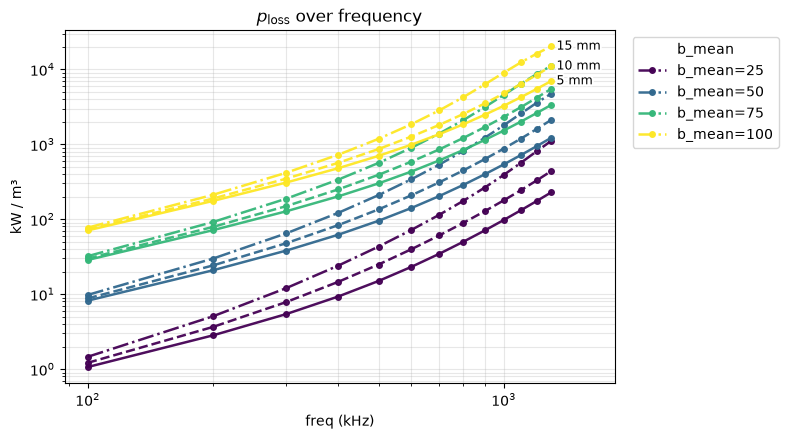

In [ ]:
selected_post_processing_key = "p_loss"
selected_post_processing = post_processing_exprs[selected_post_processing_key]


fig, ax = plt.subplots(figsize=(8, 4.5))

# Color map by geometry (w)
w_values = sorted(df["w"].unique())
cmap = plt.get_cmap("viridis", len(w_values))
w_to_color = {w: cmap(i) for i, w in enumerate(w_values)}

# Optional: linestyle by b_mean (helps distinguish curves with same color)
b_values = sorted(df["b_mean"].unique())
linestyles = ["-", "--", "-.", ":"]
b_to_ls = {b: linestyles[i % len(linestyles)] for i, b in enumerate(b_values)}

# Track one curve end per b_mean for labeling (choose highest frequency point)
label_points = {}

for (w_val, b_val), g in df.sort_values("freq").groupby(["w", "b_mean"], sort=True):
    x = g["freq"].to_numpy()
    y = (g[selected_post_processing_key] / 1000).to_numpy()  # kW/m³

    ax.plot(
        x, y,
        marker="o",
        ms=4,
        lw=1.8,
        alpha=0.95,
        color=w_to_color[w_val],      # same color for same w
        linestyle=b_to_ls[b_val],     # optional: style by b_mean
        label=f"w={w_val:.3g} mm"
    )

    # store rightmost point for b_mean label candidates
    i = np.argmax(x)
    xp, yp = x[i], y[i]
    # keep highest y at right edge for this b_mean to avoid overlap a bit
    if b_val not in label_points or (xp >= label_points[b_val][0] and yp > label_points[b_val][1]):
        label_points[b_val] = (xp, yp)

# Axes (datasheet-like)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(f"Frequency (kHz)")
ax.set_ylabel("kW / m³")
ax.set_title(f"{selected_post_processing['label']} over frequency")
ax.grid(True, which="both", alpha=0.3)

# Deduplicated legend for geometry (w)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(),
          title=r"Diameter / Width $w$", bbox_to_anchor=(1.02, 1), loc="upper left")

# Add b_mean text labels near curve ends (datasheet style)
for b_val, (xp, yp) in label_points.items():
    txt = ax.text(
        xp * 1.03, yp, f"{b_val:.3g} mT",
        fontsize=9, va="center", ha="left", color="black"
    )
    # white halo for readability
    txt.set_path_effects([pe.withStroke(linewidth=3, foreground="white")])

# Make room on right for labels
xmin, xmax = ax.get_xlim()
ax.set_xlim(xmin, xmax * 1.25)

plt.tight_layout()
plt.show()# Legend with one entry per w (deduplicate)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(
    by_label.values(),
    by_label.keys(),
    title=r"Diameter / Width $w$",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
client.remove(model)
client.clear()
client.disconnect()